# Apartado 2. Clasificador de comentarios en subreddits

En esta sección vamos a desarrollar y analizar distintos modelos de procesamiento del lenguaje para clasificación. Nuestro clasificador será capaz de recibir un comentario y predecir a que subreddit de los 6 seleccionados (books, jobs, LeagueOfLegends, RandomThoughts, travel, unpopopularopinion) pertenece el mensaje, estimando las probabilidades de pertenecer a cada uno de ellos.

Con el fin de obtener un modelo robusto e insesgado, vamos a realizar en primer lugar la división en conjunto de entrenamiento y validación.

Para ello utilizaremos los ficheros JSON limpios generados en el apartado anterior. Para la división vamos a utilizar una estrategia basada en hilos y no en comentarios individuales.

El ratio de división entre entrenamiento y validación, va a ser 70% y 30%, respectivamente.

Como ya hemos mencionado, con el fin de que nuestro modelo generalice correctamente y no memorice patrones concretos de un determinado hilo, todos los comentarios de un mismo hilo se asignará únicamente a uno de los dos conjuntos, o bien el de entrenamiento, o bien al de validación, pero nunca a ambos. En el apartado anterior hemos obtenido 59 hilos por cada subreddit, por lo que utilizaremos aproximadamente 41 hilos para entrenar y 18 para validar. Teniendo 20 comentarios por hilo, contaremos con un total de:
- 6 (subreddits) * 41 (hilos) * 20 (comentarios) = 4920 comentarios en el conjunto de entrenamiento
- 6 (subreddits) * 18 (hilos) * 20 (comentarios) = 2160 comentarios en el conjunto de validación

## Version limpio

In [1]:
import json
import regex as re
import random

subreddits = ["limpio_books.json", "limpio_jobs.json", "limpio_LeagueOfLegends.json", "limpio_RandomThoughts.json",
			  "limpio_travel.json", "limpio_unpopularopinion.json"]

X_train_limpio, X_test_limpio = [], []
# Solo hace falta hacer la variable de salida una vez, ya que es el nombre del subreddit al que pertenecen y eso
# no cambia con el preprocesamiento
y_train, y_test = [], []

proporcion = 0.7

for subreddit in subreddits:
	with open(subreddit, "r", encoding="utf-8") as file:
		datos = json.load(file)

	# Obtenemos el nombre del subreddit, ya que será nuestra salida esperada "y"
	nombre = datos["subreddit"]

	# Extraemos todos los hilos pertenecientes al subreddit
	hilos = datos["submissions"]

	# Mezclamos los hilos para que la división sea aleatoria
	random.shuffle(hilos)

	# Como hemos calculado en la explicación, en base a los hilos que tengamos en cada subreddit, utilizaremos unos
	# para entrenamiento y otros para validación. Multiplicando por la proporcion obtendremos valores con decimales
	# por lo que lo pasamos a entero, ya que los índices son enteros.
	indice = int(len(hilos) * proporcion)

	# Extraemos los hilos que pertenecerán al conjunto de entrenamiento y los que pertenecerán a la validación
	hilos_train = hilos[:indice]
	hilos_test = hilos[indice:]

	# Guardamos el texto de los comentarios en el conjunto train, aplicándole un preprocesamiento, en este caso pasar el texto a minúsculas,
	# y el subreddit al que pertenece.
	for hilo in hilos_train:
		for comentario in hilo["comments"]:
			X_train_limpio.append(comentario["body"].lower())
			y_train.append(nombre)

	# Guardamos el texto de los comentarios en el conjunto test, aplicándole un preprocesamiento, en este caso pasar el texto a minúsculas,
	# y el subreddit al que pertenece.
	for hilo in hilos_test:
		for comentario in hilo["comments"]:
			X_test_limpio.append(comentario["body"].lower())
			y_test.append(nombre)

## Version completo

In [2]:
import json
import regex as re
import random

subreddits = ["completo_books.json", "completo_jobs.json", "completo_LeagueOfLegends.json", "completo_RandomThoughts.json",
			  "completo_travel.json", "completo_unpopularopinion.json"]

X_train_completo, X_test_completo = [], []

proporcion = 0.7

for subreddit in subreddits:
	with open(subreddit, "r", encoding="utf-8") as file:
		datos = json.load(file)

	# Obtenemos el nombre del subreddit, ya que será nuestra salida esperada "y"
	nombre = datos["subreddit"]

	# Extraemos todos los hilos pertenecientes al subreddit
	hilos = datos["submissions"]

	# Mezclamos los hilos para que la división sea aleatoria
	random.shuffle(hilos)

	# Como hemos calculado en la explicación, en base a los hilos que tengamos en cada subreddit, utilizaremos unos
	# para entrenamiento y otros para validación. Multiplicando por la proporcion obtendremos valores con decimales
	# por lo que lo pasamos a entero, ya que los índices son enteros.
	indice = int(len(hilos) * proporcion)

	# Extraemos los hilos que pertenecerán al conjunto de entrenamiento y los que pertenecerán a la validación
	hilos_train = hilos[:indice]
	hilos_test = hilos[indice:]

	# Guardamos el texto de los comentarios en el conjunto train, aplicándole un preprocesamiento, en este caso pasar el texto a minúsculas,
	# y el subreddit al que pertenece.
	for hilo in hilos_train:
		for comentario in hilo["comments"]:
			X_train_completo.append(comentario["body"].lower())

	# Guardamos el texto de los comentarios en el conjunto test, aplicándole un preprocesamiento, en este caso pasar el texto a minúsculas,
	# y el subreddit al que pertenece.
	for hilo in hilos_test:
		for comentario in hilo["comments"]:
			X_test_completo.append(comentario["body"].lower())

In [3]:
# Comprobamos que el resultado obtenido es el que habíamos calculado previamente
print(f"Conjunto de entrenamiento: Hemos obtenido {len(X_train_limpio)} comentarios")
print(f"Conjunto de validación: Hemos obtenido {len(X_test_limpio)} comentarios")

Conjunto de entrenamiento: Hemos obtenido 4920 comentarios
Conjunto de validación: Hemos obtenido 2160 comentarios


In [4]:
# Comprobamos que el resultado obtenido es el que habíamos calculado previamente
print(f"Conjunto de entrenamiento: Hemos obtenido {len(X_train_completo)} comentarios")
print(f"Conjunto de validación: Hemos obtenido {len(X_test_completo)} comentarios")

Conjunto de entrenamiento: Hemos obtenido 4920 comentarios
Conjunto de validación: Hemos obtenido 2160 comentarios


Una vez hemos obtenido los conjuntos necesarios para continuar con el siguiente paso donde usaremos distintos tipos de representación de textos para hacer esta clasificación.
# ... escribir explicación inicial

En este apartado, desarrollamos un clasificador automático capaz de predecir a qué comunidad de Reddit pertenece un comentario determinado.

Para determinar qué técnica ofrece un mejor rendimiento, aplicaremos tres sistemas distintos:
- Un primer sistema basado en representaciones de texto mediante TF-IDF, utilizando algoritmos de clasificación clásicos como Linear Support Vector Machines.
- Un segundo sistema fundamentado en el uso de Word-Embeddings (Doc2Vec), que nos permite capturar relaciones semánticas entre palabras.
- Un tercer sistema basado en modelos de Transformers, donde realizaremos un proceso de fine-tuning sobre modelos preentrenados (BERT) para adaptarlos específicamente a nuestra tarea de clasificación.

## Vamos a comenzar con el primer enfoque. En este aplicaremos un modelo de clasificación sencillo y tipos de características.

Primero lo realizaremos sin el preprocesado aplicado en el apartado 1. Es decir, usaremos los archivos cuyo nombre comience por "completo_".

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,  accuracy_score, confusion_matrix

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Función auxiliar para visualizar la matriz de confusión en forma de gráfico para facilitar el análisis que realizaremos
def plot_matriz_confusion(matriz_confusion, titulo, ejes):
	plt.figure(figsize=(10,8))

	sns.heatmap(matriz_confusion, annot=True, xticklabels=ejes, yticklabels=ejes, cmap="Blues", fmt="d")

	plt.title(titulo, fontsize=15)
	plt.xlabel("Predicción")
	plt.ylabel("Valor real")
	plt.show()

In [7]:
import pandas as pd

# Función auxiliar para visualizar la matriz de confusión en forma de gráfico para facilitar el análisis que realizaremos
def plot_informe_resultados(diccionario_informe, titulo):
	# Para tener en las filas los distintos subreddits y en las columnas las métricas
	df = pd.DataFrame(diccionario_informe).transpose()
	df = df.drop(["accuracy", "weighted avg", "macro avg"])

	plt.figure(figsize=(10,8))

	# Quito la métrica support también
	sns.heatmap(df.iloc[:, :-1], annot=True, cmap="Blues", fmt=".2f")

	plt.title(titulo, fontsize=15)
	plt.xlabel("Métricas")
	plt.ylabel("Subreddits")
	plt.show()

In [8]:
# Añadimos una variable configuraciones para poder iterar sobre ella y aplicar más fácil todos los tipos de
# características pedidos en la práctica
configuraciones = {"Unigramas": (1, 1, "word"),
				   "Bigramas": (2, 2, "word"),
				   "Trigramas": (3, 3, "word"),
				   "Char-n-gramas": (3, 5, "char")}        # De 3 a 5 caracteres como hicimos en la práctica 6.2

# Añadimos otra variable para hacer con ambos conjuntos de entrenamiento y validación. Los completos, obtenidos directamente de reddit
# y los limpios, a los que hemos aplicado un preprocesado, eliminando mensajes que solo contienen URL, mensajes de bots, stopwords...
datasets = {"Completos": (X_train_completo, X_test_completo),
			"Limpios": (X_train_limpio, X_test_limpio)}

# Diccionario vacío para guardar todos los resultados y examinarlos más adelante
resultados = {}

# Iteramos por ambos conjuntos de entrenamiento
for datos, (X_train, X_test) in datasets.items():
	print(f"Dataset de datos {datos}\n")

	# Ahora iteramos por las configuraciones, creando el modelo correspondiente y mostramos los resultados
	for config, (minimo, maximo, tipo) in configuraciones.items():
		clf_tfidf = Pipeline([
		('vect', CountVectorizer(analyzer=tipo, ngram_range=(minimo, maximo))),
		('tf_idf', TfidfTransformer()),
		('clf', LinearSVC(random_state=23, tol=1e-5)),])

		clf_tfidf.fit(X_train, y_train)

		y_pred = clf_tfidf.predict(X_test)

		# Para que salga en formato diccionario y poder convertirlo a DataFrame y visualizarlo
		report = classification_report(y_test, y_pred, output_dict=True)
		matriz = confusion_matrix(y_test, y_pred)
		accuracy = accuracy_score(y_test, y_pred)

		etiquetas= clf_tfidf.classes_

		resultados[(datos, config)] = {"Accuracy": accuracy,
										"Informe de resultados": report,
										"Matriz de confusión": matriz,
										"Etiquetas": etiquetas}

		print("---------------------------------------------------------\n")
		print(f"Resultados para la configuración {config}")
		print(f"Accuracy = {accuracy}\n")

Dataset de datos Completos

---------------------------------------------------------

Resultados para la configuración Unigramas
Accuracy = 0.5486111111111112

---------------------------------------------------------

Resultados para la configuración Bigramas
Accuracy = 0.4300925925925926

---------------------------------------------------------

Resultados para la configuración Trigramas
Accuracy = 0.3023148148148148

---------------------------------------------------------

Resultados para la configuración Char-n-gramas
Accuracy = 0.5449074074074074

Dataset de datos Limpios

---------------------------------------------------------

Resultados para la configuración Unigramas
Accuracy = 0.549537037037037

---------------------------------------------------------

Resultados para la configuración Bigramas
Accuracy = 0.35833333333333334

---------------------------------------------------------

Resultados para la configuración Trigramas
Accuracy = 0.19722222222222222

------------

Solo vamos a analizar las configuraciones con accuracy mayor que 0,5.

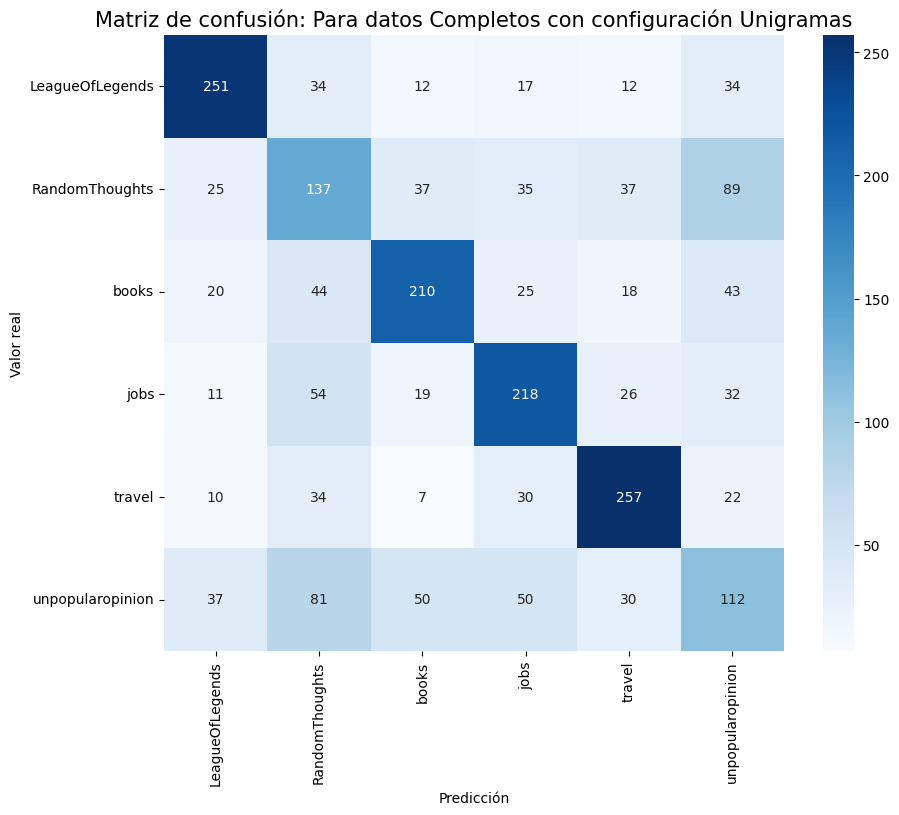

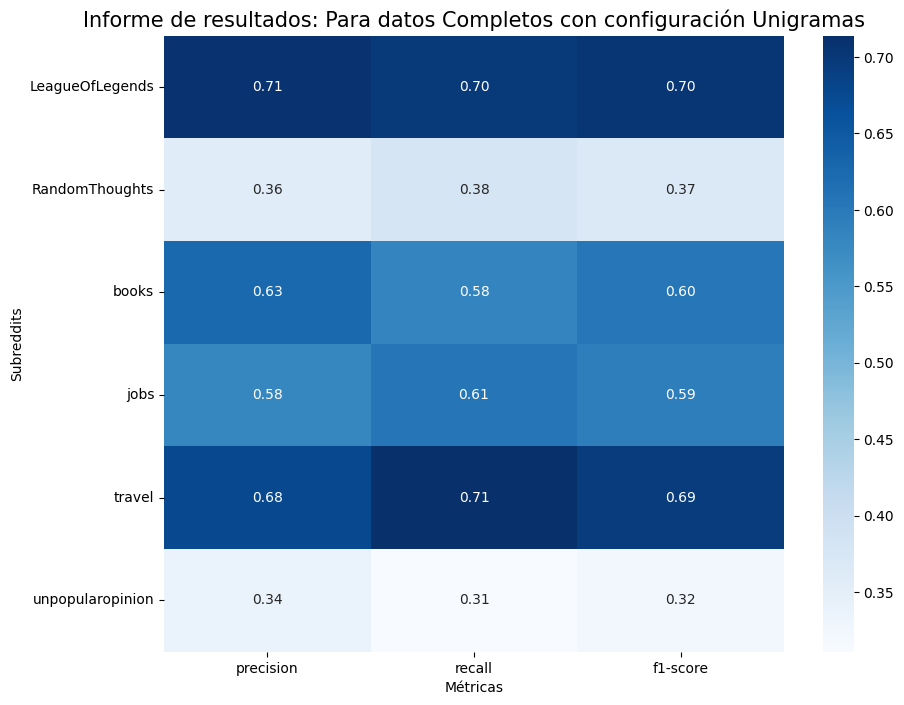

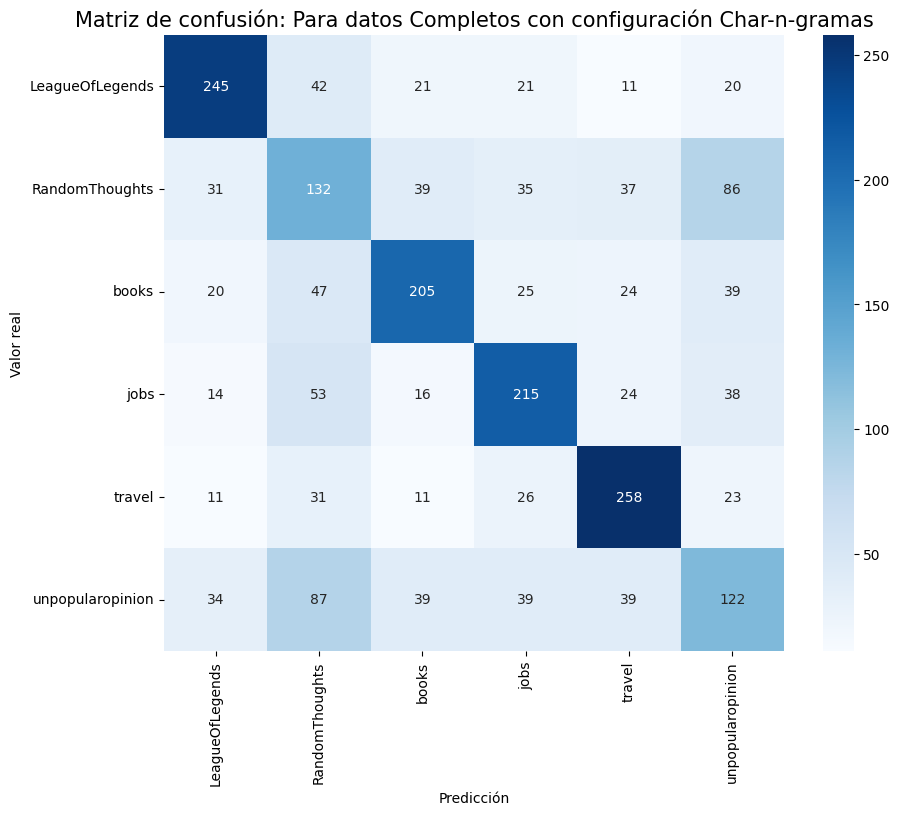

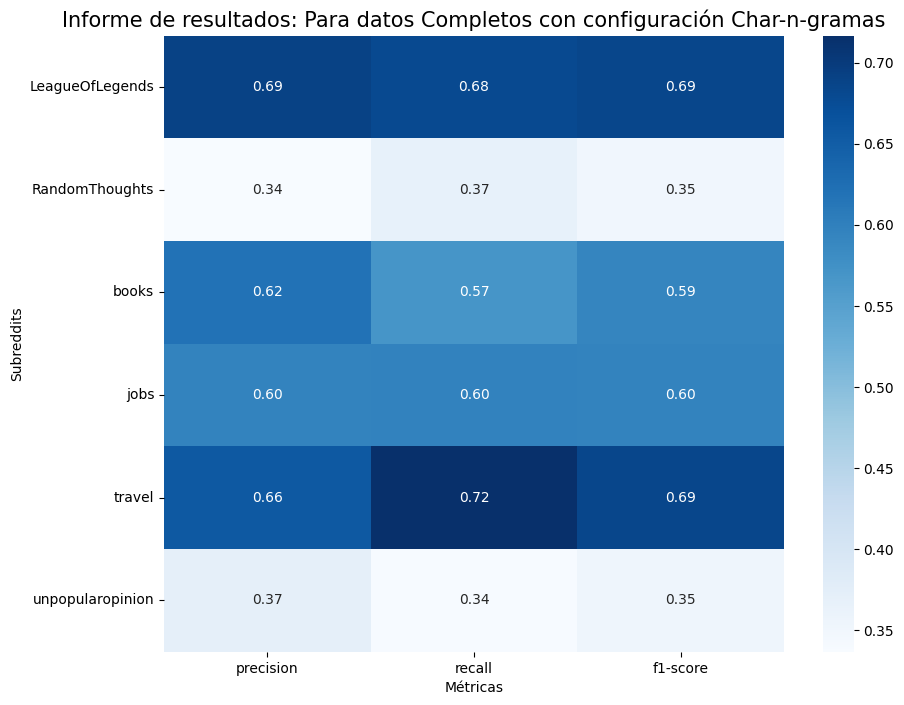

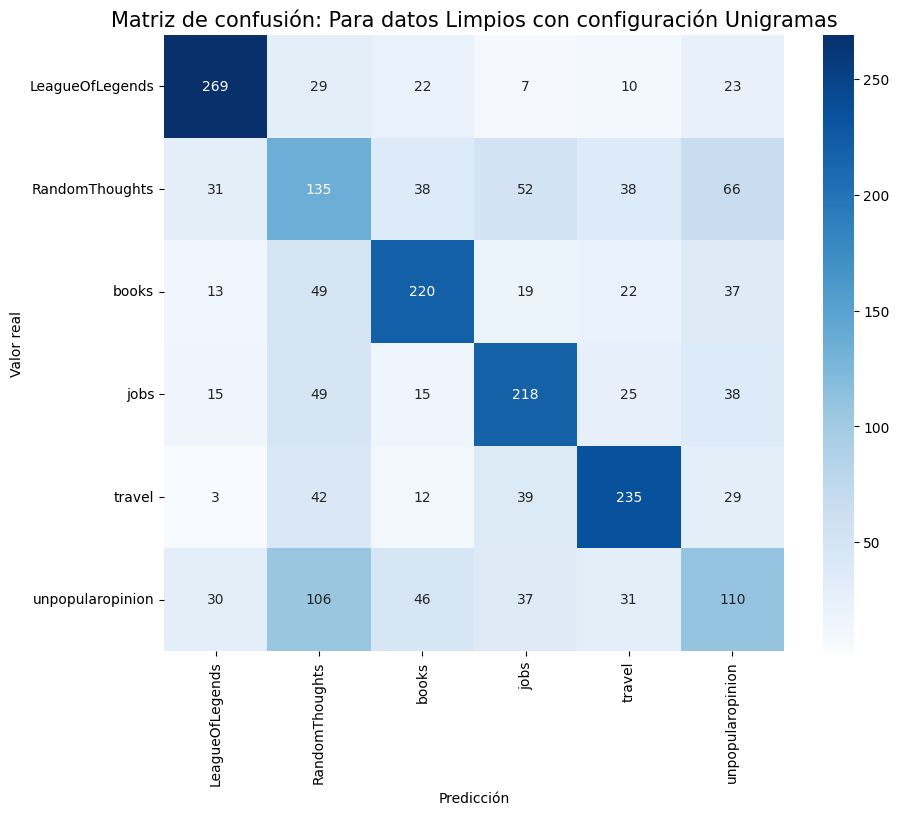

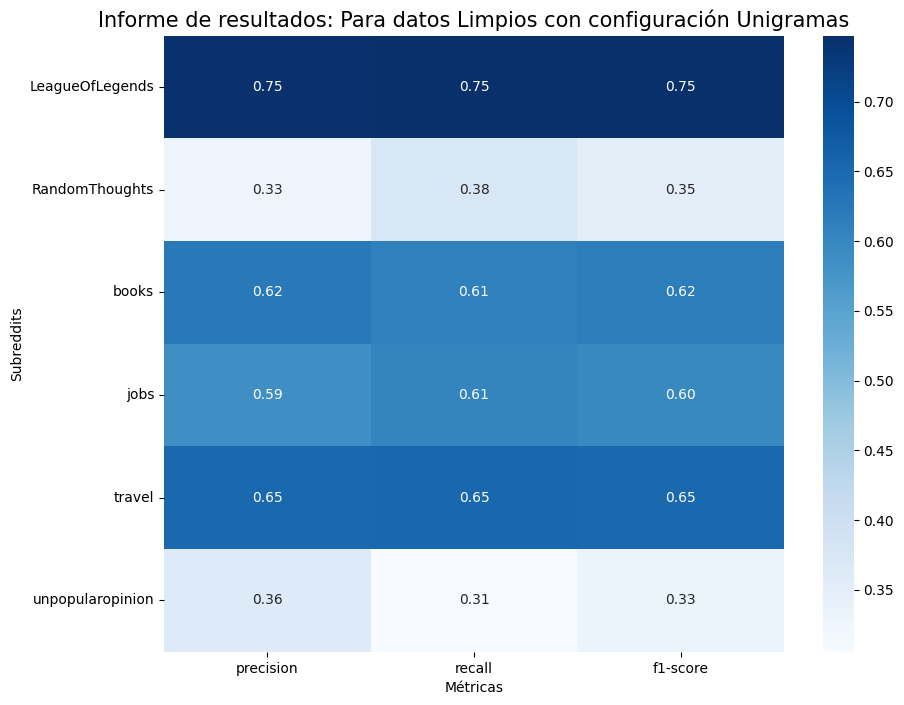

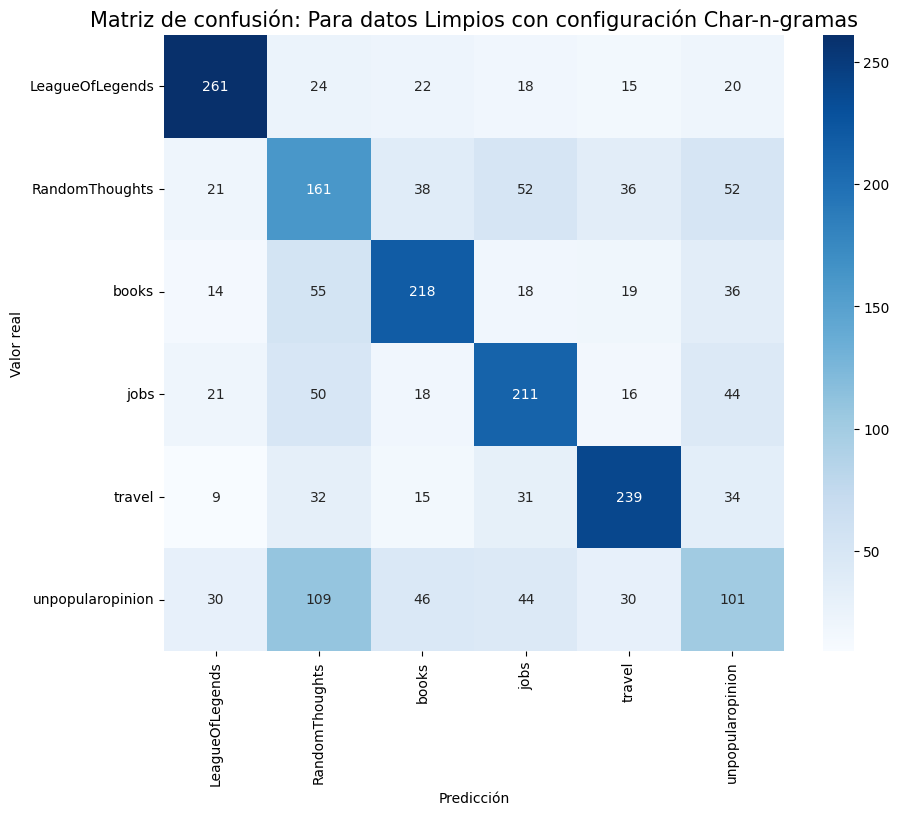

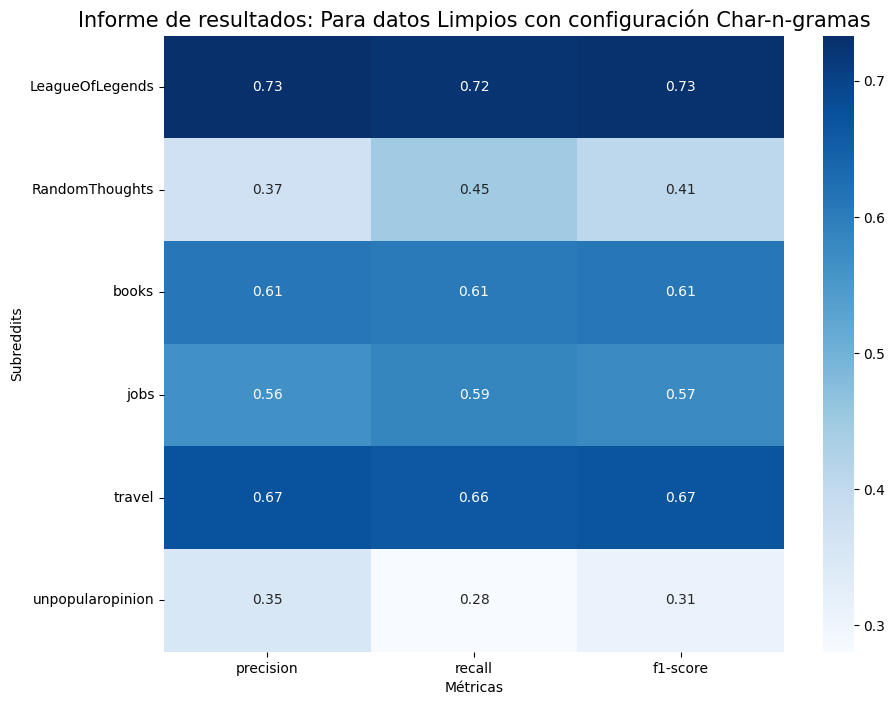

In [10]:
for (datos, config), diccionario in resultados.items():
	if diccionario["Accuracy"] > 0.5:
		titulo = f"Matriz de confusión: Para datos {datos} con configuración {config}"
		plot_matriz_confusion(diccionario["Matriz de confusión"], titulo, etiquetas)

		titulo = f"Informe de resultados: Para datos {datos} con configuración {config}"
		plot_informe_resultados(diccionario["Informe de resultados"], titulo)

# pequeña reflexion de resultados

Análizando estos resultados, observamos lo siguiente:

- **Eficacia de los Unigramas**: Hemos observado que las palabras individuales (**unigramas**) son suficientes para captar la temática en muchas ocasiones, alcanzando un accuracy del $54.86\%$ en el dataset completo y $54.95\%$ en el dataset limpio. Así concluimos que no es necesario almacenar los n-gramas y simplemente almacenando y teniendo en cuenta los unigramas obtenemos prácticamente el mismo resultado.

- **Problemas de Dispersión**: Hemos notado que el uso de bigramas o trigramas degrada drásticamente el rendimiento (bajando hasta un $19\%$ en el corpus limpio), lo que nos indica que las secuencias de varias palabras son demasiado específicas para que el modelo aprenda patrones útiles en este volumen de datos.   

Esta base nos sirve para contrastar si los siguientes modelos, capaces de entender el contexto y la semántica, logran superar la barrera del $55\%$ de precisión que el modelo léxico simple no ha podido traspasar.

## Segundo sistema

In [15]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [12]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.7 MB/s eta 0:00:00


In [16]:
from gensim.models import Doc2Vec
from gensim.models import Word2Vec
from gensim.models.doc2vec import TaggedDocument

# Añadimos una variable para poder iterar sobre ambos conjuntos de entrenamiento y validación de una
datasets = {"Completos": (X_train_completo, X_test_completo),
			"Limpios": (X_train_limpio, X_test_limpio)}

# Añadimos otra variable para poder variar las dimensiones
configuraciones = {
	"Doc2Vec 50 dimensiones": 50,
	"Doc2Vec 100 dimensiones": 100,
	"Doc2Vec 200 dimensiones": 200
}

# Diccionario vacío para guardar todos los resultados y examinarlos más adelante
resultados = {}

# Iteramos por ambos conjuntos de entrenamiento
for datos, (X_train, X_test) in datasets.items():
	print(f"Dataset de datos {datos}\n")

	# Solo es necesario hacerlo una vez para cada conjunto de datos
	X_train_tokens = [word_tokenize(texto) for texto in X_train]
	X_test_tokens = [word_tokenize(texto) for texto in X_test]

	# Necestiamos crear un TaggedDocument para cada uno de los textos indicando un índice de cada texto
	# Es necesario el indice, creamos uno para cada texto de entrenamiento
	tagged_data = [TaggedDocument(words=tokens, tags=[str(i)]) for i, tokens in enumerate(X_train_tokens)]

	# Ahora iteramos por las configuraciones, creando el modelo correspondiente y mostramos los resultados
	for config, vec_size in configuraciones.items():

		# Entrenar Doc2Vec
		doc2vec_model = Doc2Vec(vector_size=vec_size,
						alpha=0.025,
						min_alpha=0.00025,
						min_count=1,
						dm = 1,
						epochs = 5)

		doc2vec_model.build_vocab(tagged_data)

		# Vectorización
		X_train_vec = [doc2vec_model.infer_vector(texto) for texto in X_train_tokens]
		X_test_vec = [doc2vec_model.infer_vector(texto) for texto in X_test_tokens]

		# Creamos el clasificador
		clf_d2v = LinearSVC(random_state=23, tol=1e-15)
		clf_d2v.fit(X_train_vec, y_train)

		y_pred = clf_d2v.predict(X_test_vec)

		# Para que salga en formato diccionario y poder convertirlo a DataFrame y visualizarlo
		report = classification_report(y_test, y_pred, output_dict=True)
		matriz = confusion_matrix(y_test, y_pred)
		accuracy = accuracy_score(y_test, y_pred)

		resultados[(datos, config)] = {"Accuracy": accuracy,
										"Informe de resultados": report,
										"Matriz de confusión": matriz,
										}

		print("---------------------------------------------------------\n")
		print(f"Resultados para la configuración {config}")
		print(f"Accuracy = {accuracy}\n")

Dataset de datos Completos

---------------------------------------------------------

Resultados para la configuración Doc2Vec 50 dimensiones
Accuracy = 0.17407407407407408

---------------------------------------------------------

Resultados para la configuración Doc2Vec 100 dimensiones
Accuracy = 0.1699074074074074

---------------------------------------------------------

Resultados para la configuración Doc2Vec 200 dimensiones
Accuracy = 0.17222222222222222

Dataset de datos Limpios

---------------------------------------------------------

Resultados para la configuración Doc2Vec 50 dimensiones
Accuracy = 0.15787037037037038

---------------------------------------------------------

Resultados para la configuración Doc2Vec 100 dimensiones
Accuracy = 0.1537037037037037

---------------------------------------------------------

Resultados para la configuración Doc2Vec 200 dimensiones
Accuracy = 0.15



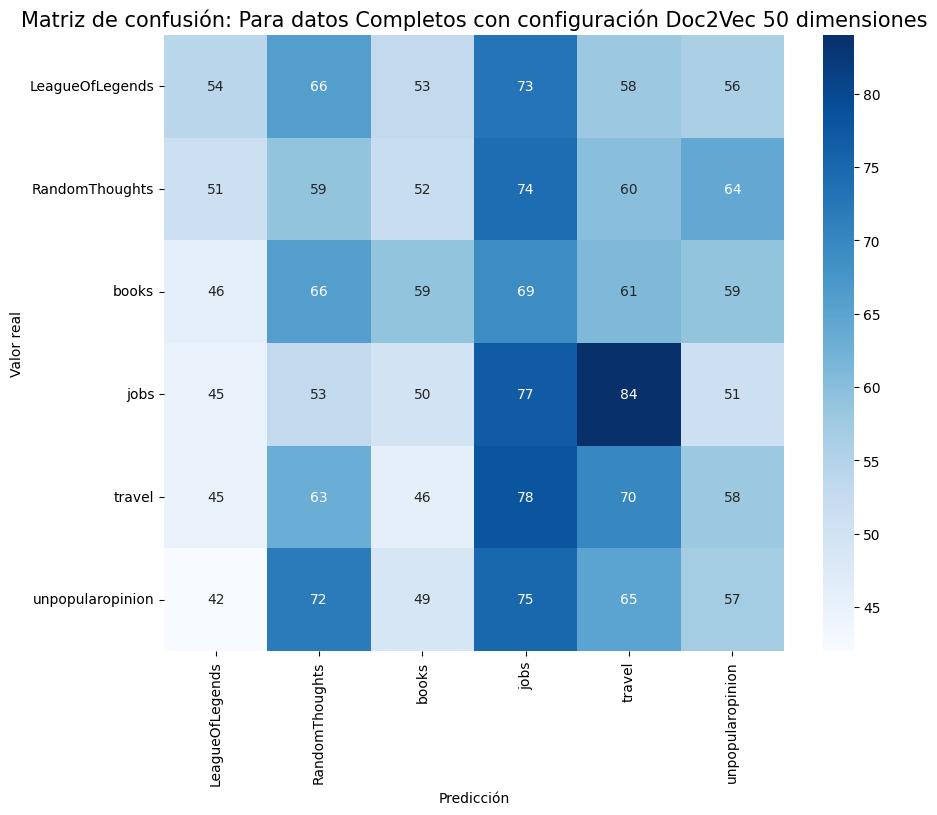

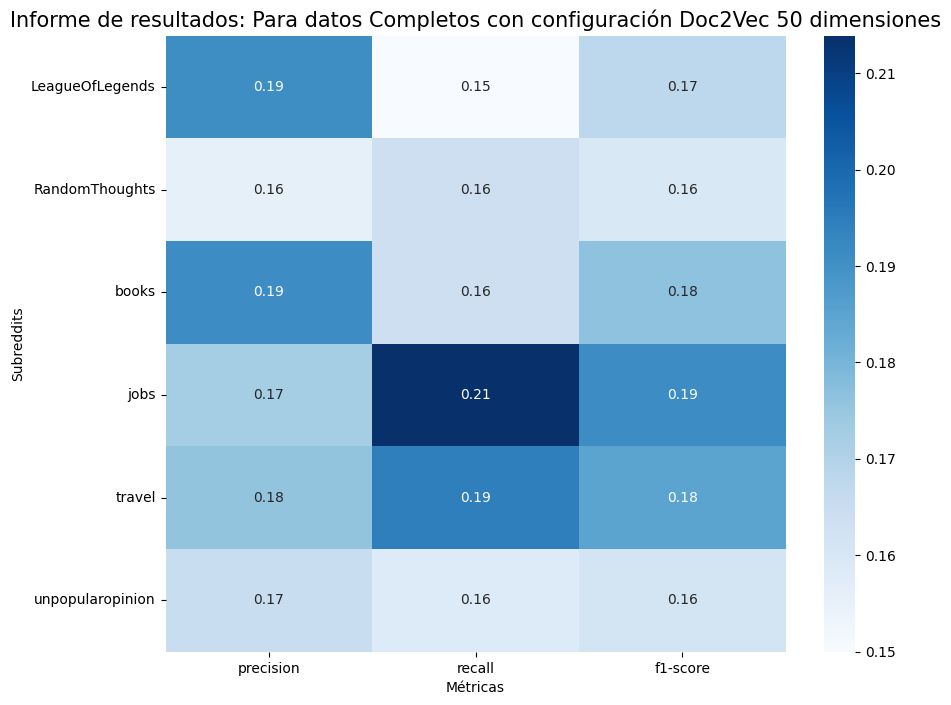

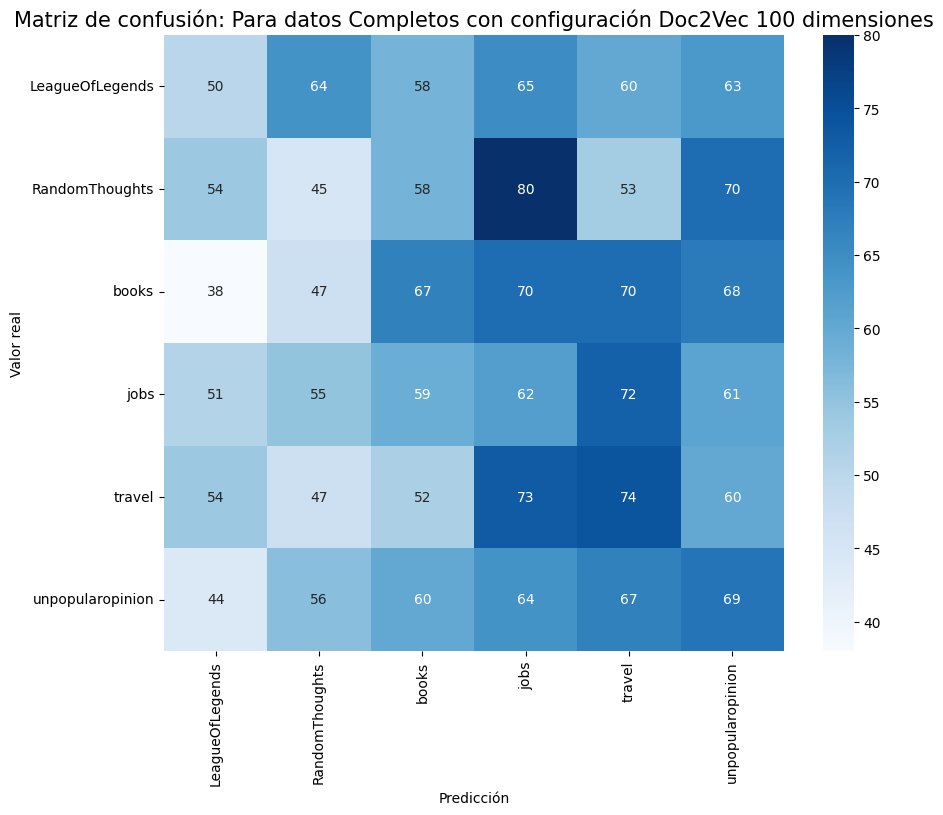

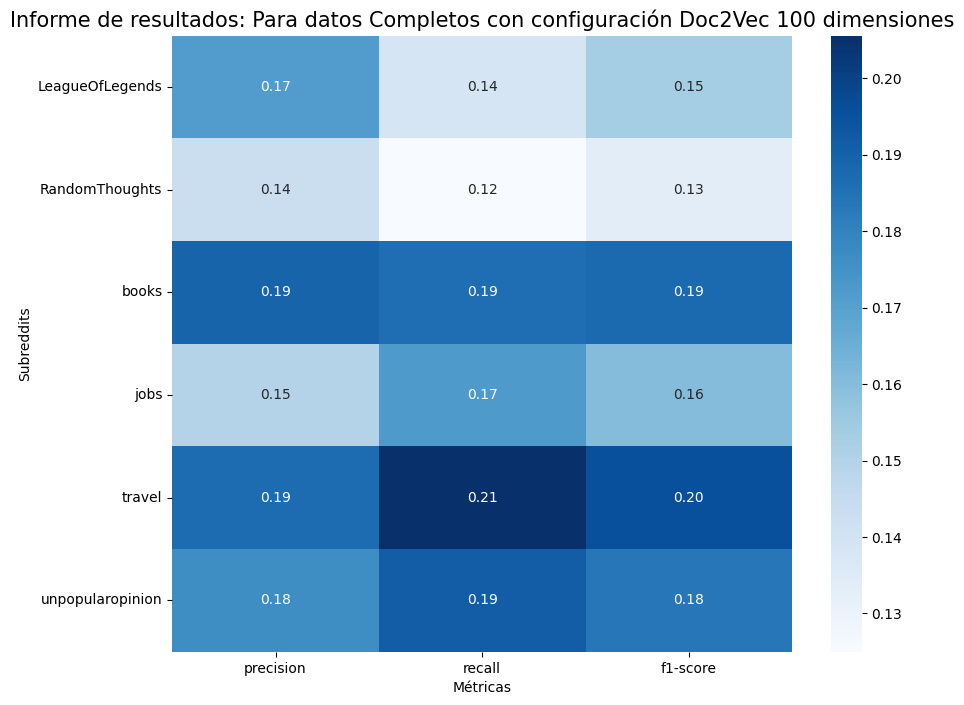

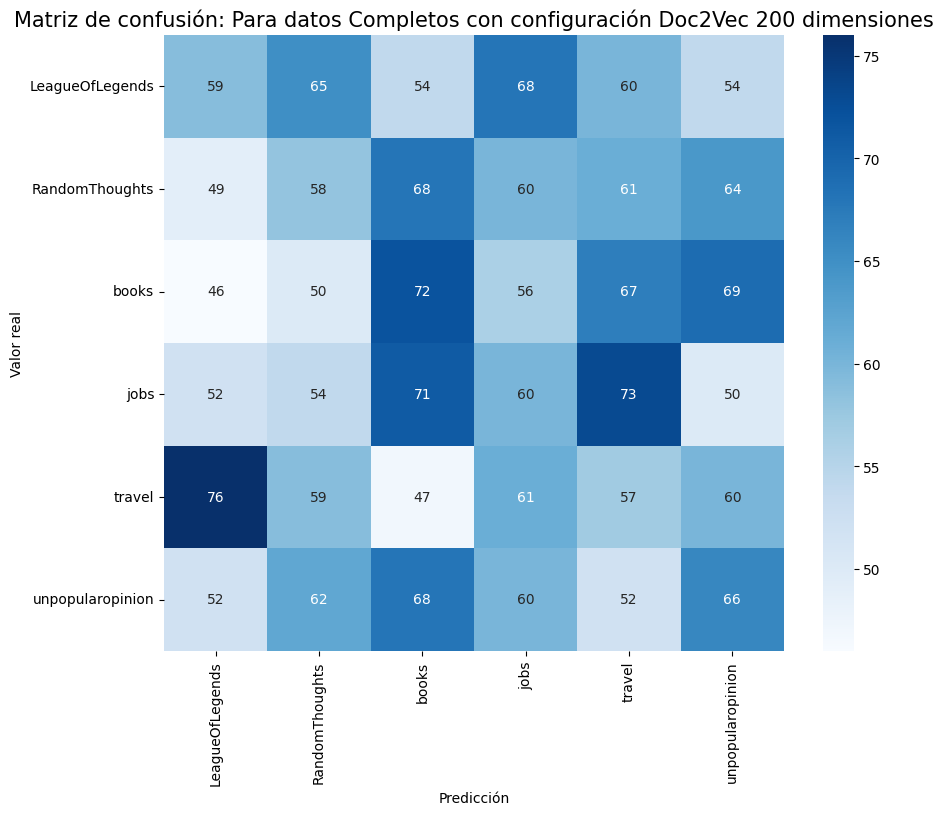

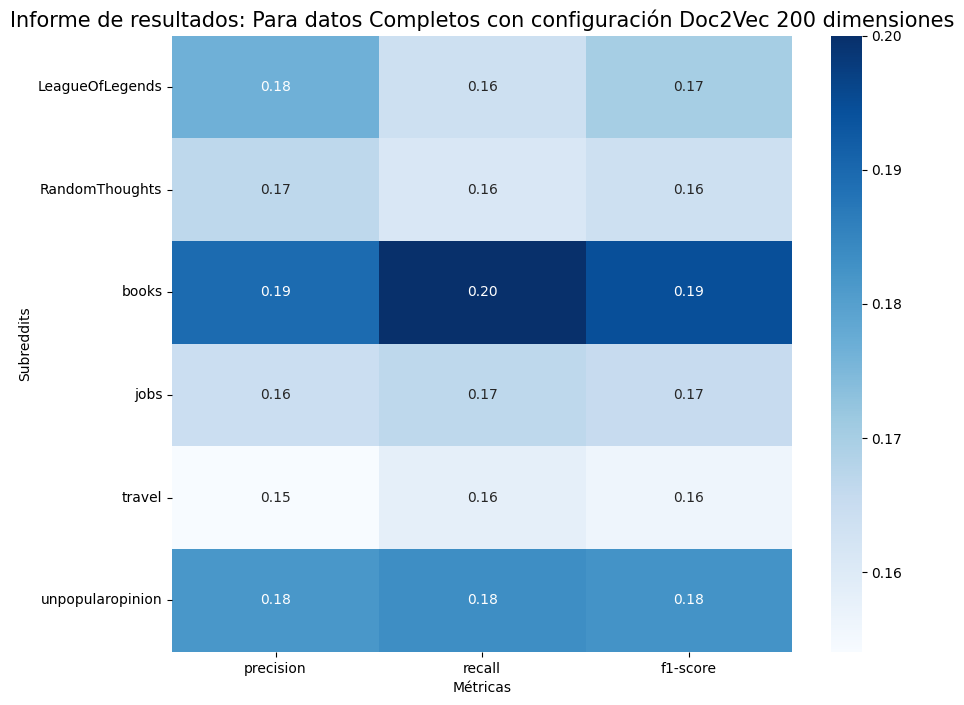

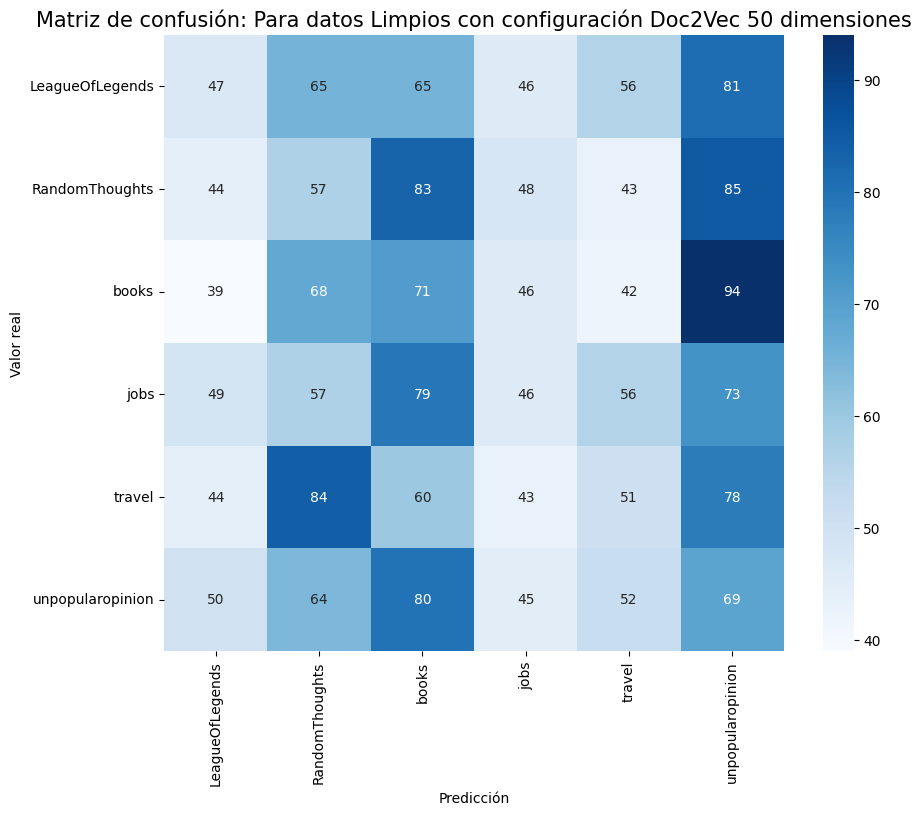

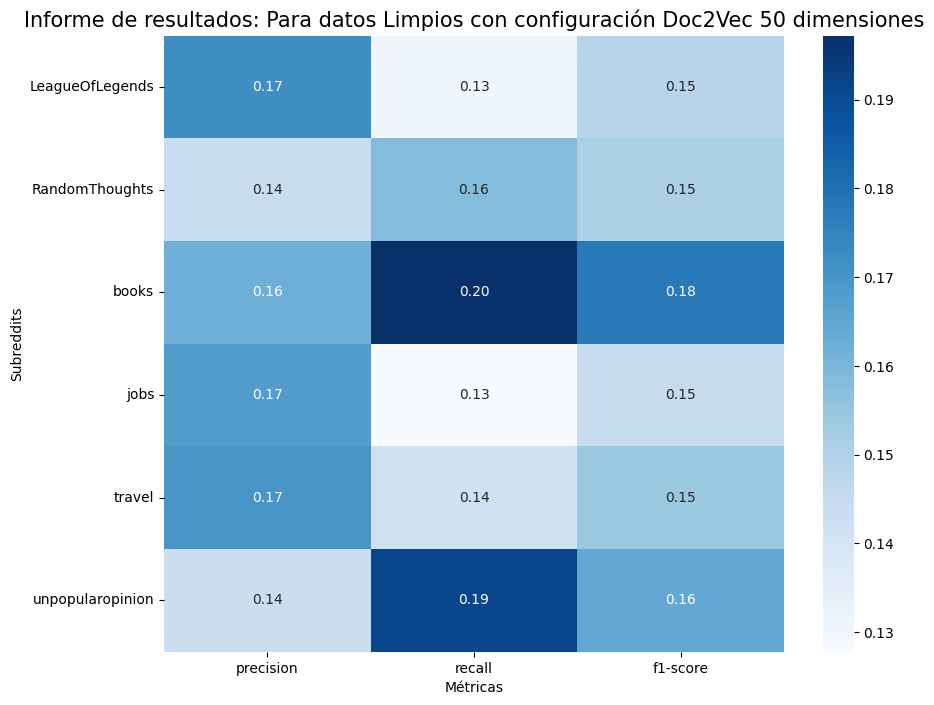

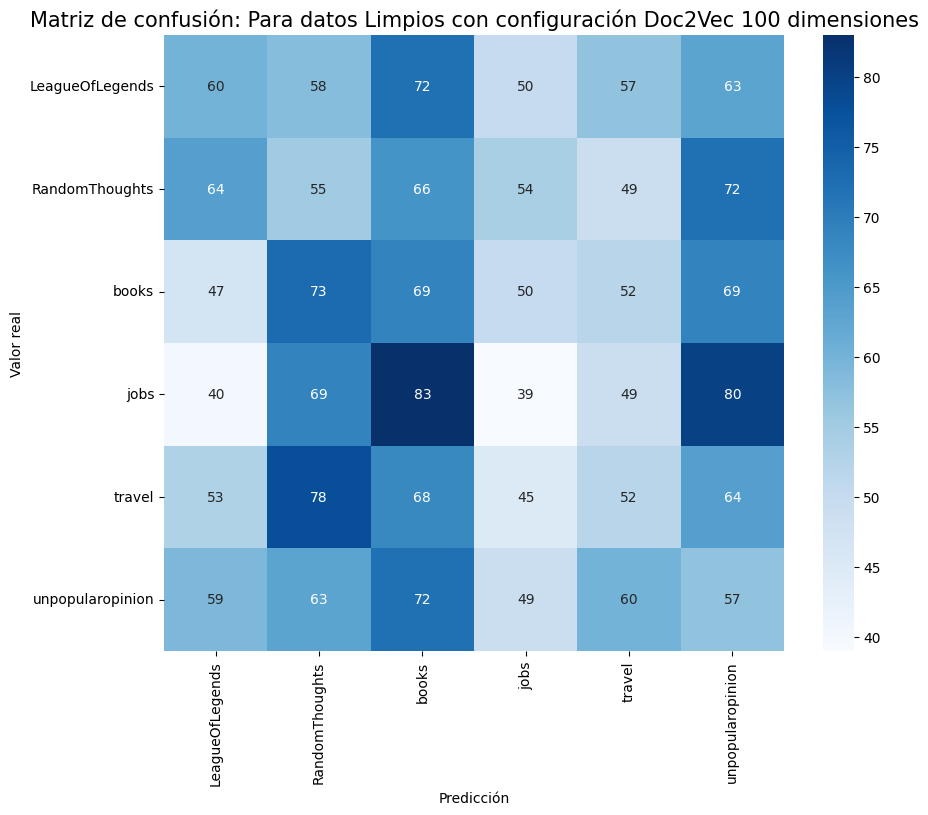

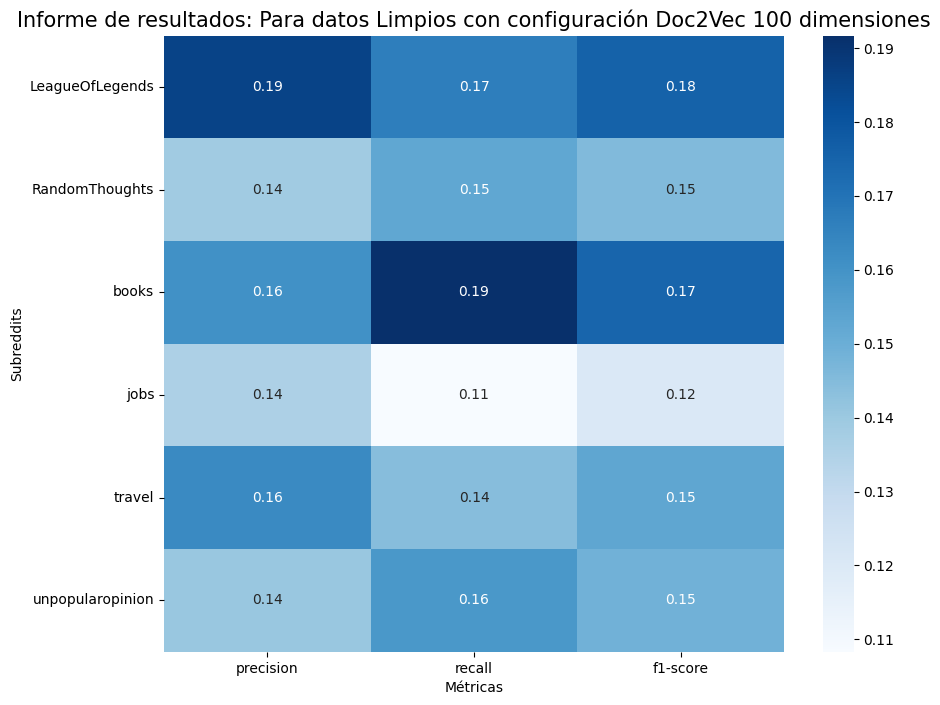

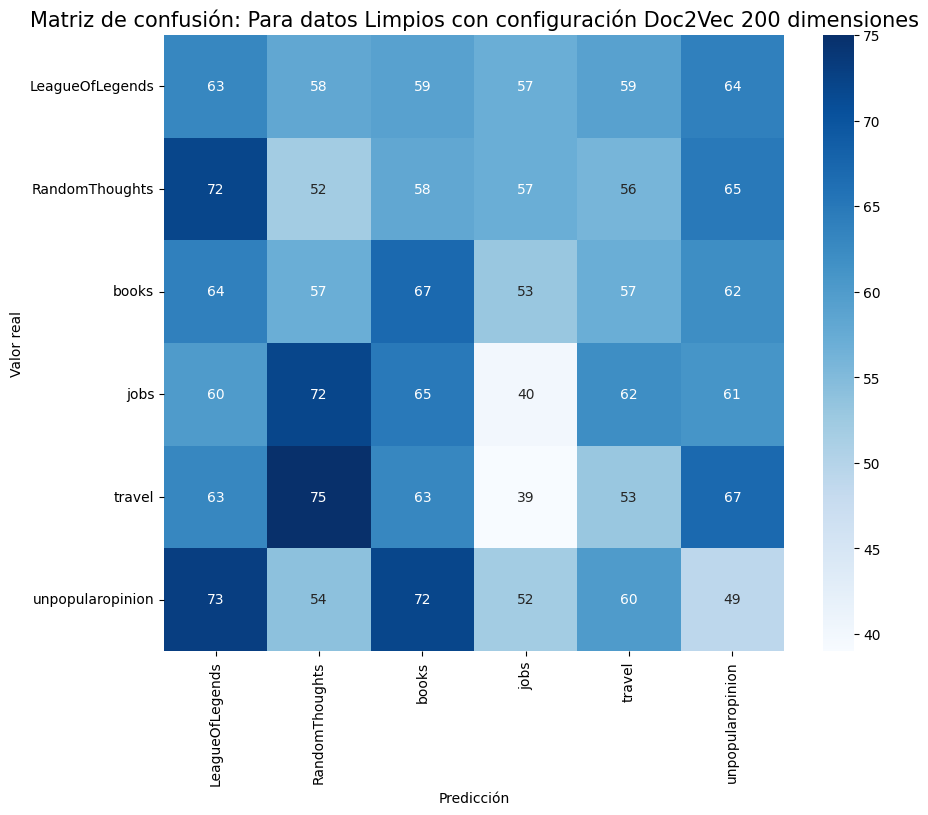

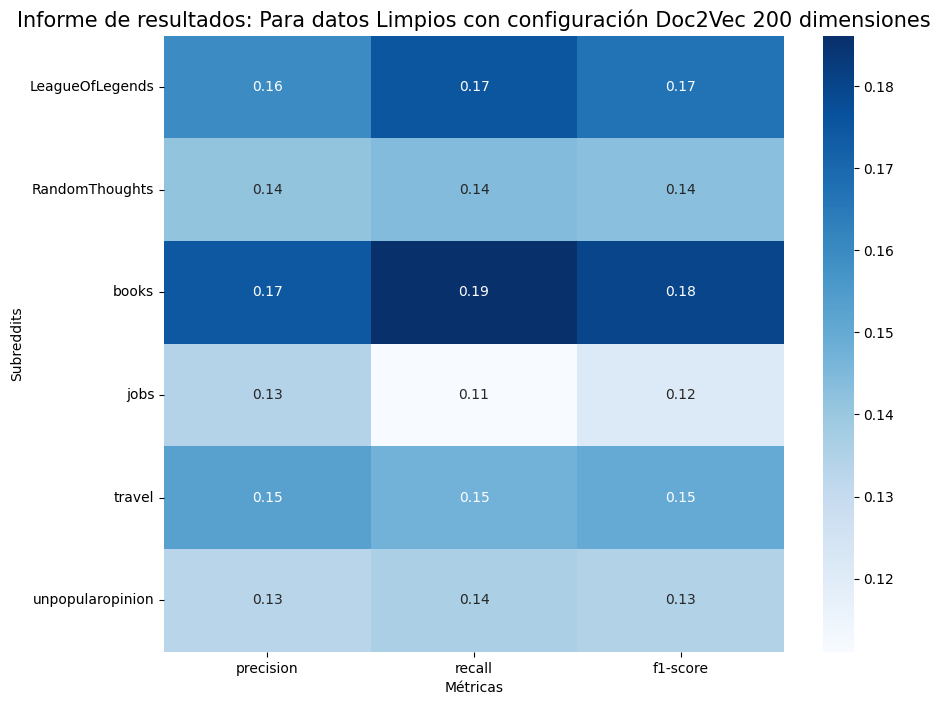

In [17]:
for (datos, config), diccionario in resultados.items():
	titulo = f"Matriz de confusión: Para datos {datos} con configuración {config}"
	plot_matriz_confusion(diccionario["Matriz de confusión"], titulo, etiquetas)

	titulo = f"Informe de resultados: Para datos {datos} con configuración {config}"
	plot_informe_resultados(diccionario["Informe de resultados"], titulo)

## Último sistema

Vamos a comprobar el idioma de nuestros datasets, el original y el preprocesado, para decidir el modelo Masked Language Model a utilizar

In [19]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 33.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=847fbbb834335189b3820fe732ec4d88a33ac8ec6f7c5178e67d494f07251666
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [20]:
from langdetect import detect
import pandas as pd

def detectar_idioma(texto):
    try:
        return detect(texto)
    except:
        return "unknown"

idiomas_limpio = [detectar_idioma(t) for t in X_train_limpio]
idiomas_completo = [detectar_idioma(t) for t in X_train_completo]

display(pd.Series(idiomas_limpio).value_counts(normalize=True) * 100)
display(pd.Series(idiomas_completo).value_counts(normalize=True) * 100)

,proportion
en,87.560976
af,1.971545
fr,1.260163
no,1.138211
nl,0.813008
da,0.772358
it,0.711382
cy,0.650407
es,0.569106
tl,0.569106


,proportion
en,95.304878
af,0.569106
no,0.447154
cy,0.406504
fr,0.365854
da,0.345528
et,0.325203
it,0.284553
tl,0.284553
es,0.223577


“El análisis de distribución de idiomas muestra que el 87.24% del conjunto de entrenamiento preprocesado corresponde a texto en inglés, porcentaje que aumenta hasta el 95.26% original. El resto de idiomas aparece de forma residual y altamente dispersa.”
“Este resultado justifica el uso de modelos preentrenados en inglés como BERT uncased, ya que la variabilidad lingüística del dataset es mínima.”

Como ya descubrimos en el notebook de [estadisticos](estadisticos.ipynb), el $96.5\%$ del **Corpus** se encuentra escrito en inglés. Este resultado justifica el uso del modelo preentrenado en inglés *BERT-uncased*, ya que la variabilidad lingüística del dataset es mínima.

In [21]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [22]:
# En pytorch, los datasets se preparan de manera distinta a Tensorflow
class PLNEDataset(torch.utils.data.Dataset):
	def __init__(self, encodings, labels):
		self.encodings = encodings
		self.labels = labels

	def __getitem__(self, idx):
		item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
		item['labels'] = torch.tensor(self.labels[idx])
		return item

	def __len__(self):
		return len(self.labels)

In [25]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "f1": f1_score(labels, preds, average="macro")
    }

In [26]:
# Fijamos semilla para garantizar reproducibilidad.
SEED = 23
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

############## Definición y carga del modelo ##############

# Al ser siempre los mismos valores, el tokenizador sse extrae del modelo, no depende de nuestros dataos, lo cargamos una unica vez
# Definimos el modelo a utilizar
ruta_modelo = 'bert-base-uncased'

# Cargamos el tokenizer
tokenizer = AutoTokenizer.from_pretrained(ruta_modelo)

# Añadimos una variable para poder iterar sobre ambos conjuntos de entrenamiento y validación de una
datasets = {"Completos": (X_train_completo, X_test_completo),
						"Limpios": (X_train_limpio, X_test_limpio)}

resultados = {}

# Iteramos por ambos conjuntos de entrenamiento
for dataset, (X_train, X_test) in datasets.items():
	print(f"Dataset de datos {dataset}\n")

	# Definimos la traducción de las etiquetas
	labels = sorted(list(set(y_train)))
	id2label = {i: label for i, label in enumerate(labels)}
	label2id = {label: i for i, label in enumerate(labels)}

	# Establecemos el número de etiquetas
	# Vamos a realizar clasificación en nuestros distintos subreddits, por lo tanto el número de etiquetas es 6
	NUM_LABELS = len(labels)

	# Cargamos el modelo (usando pytorch)
	modelo = AutoModelForSequenceClassification.from_pretrained(ruta_modelo,
															 	num_labels=NUM_LABELS)

	# Le pasamos la traducción de las etiquetas al modelo
	modelo.config.id2label = id2label
	modelo.config.label2id = label2id

	############## Preparación de los conjuntos de datos ##############
	df_train = pd.DataFrame({
		"text": X_train,
		"label": y_train
	})
	df_test = pd.DataFrame({
		"text": X_test,
		"label": y_test
	})

	# Codificación
	df_train['_label'] = df_train['label'].apply(lambda x: label2id[x])
	df_test['_label'] = df_test['label'].apply(lambda x : label2id[x])

	# Partimos el conjunto de train en train y evaluación
	df_train, df_eval = train_test_split(df_train, test_size=0.2, random_state=23)

	# Tokenizador
	tokenized_train_dataset = tokenizer(df_train.text.tolist(),  truncation=True, padding = True)
	tokenized_eval_dataset = tokenizer(df_eval.text.tolist(), truncation=True, padding = True)
	tokenized_test_dataset = tokenizer(df_test.text.tolist(), truncation=True, padding = True)

	# Como antes, las etiquetas deben ser numéricas para poder entrenar.
	# Preparamos los 3 datasets para hacer el finetuning
	train_dataset = PLNEDataset(tokenized_train_dataset, df_train._label.tolist())
	eval_dataset = PLNEDataset(tokenized_eval_dataset, df_eval._label.tolist())
	test_dataset = PLNEDataset(tokenized_test_dataset, df_test._label.tolist())

	############## Definición de hiperparámetros de entrenamiento y de trainer ##############

	# Tamaño del batch para entrenamiento
	batch_train_size = 16

	# Tamaño del batch para evaluación
	batch_val_size = 64

	# Métrica usada para elegir el mejor modelo
	metric_name = "eval_f1"

	training_args = TrainingArguments (
		output_dir = f'./results{dataset}', # donde guardar el modelo entrenado
		logging_dir = f'./logs{dataset}', # donde guardar los logs del entrenamiento
		num_train_epochs=3,  # Número de épocas
		eval_strategy="epoch",  # Estrategia de evaluación (epoch / step)
		save_strategy="epoch", # Estrategia de guardado del modelo (epoch / step)
		per_device_train_batch_size = batch_train_size, # Tamaño del batch para entrenamiento
		per_device_eval_batch_size = batch_val_size, # Tamaño del batch para evaluación
		metric_for_best_model=metric_name,  # Métrica usada para elegir el mejor modelo
		save_total_limit=1, # Número máximo de checkpoints a guardar
		load_best_model_at_end=True, # Carga el mejor modelo al final
		report_to="none"  # Desactiva wandb (Weights and Biases)
	)

	# Se encarga de partir el texto en lotes (batches) y añadir el padding necesario
	# Usamos un DataCollatorWithPadding para padding dinámico
	data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

	# Objeto que simplifica el proceso de entrenamiento y evaluación
	trainer = Trainer (
			model = modelo, # modelo
			args = training_args, # hiperparámetros de entreamiento
			train_dataset = train_dataset, # conjunto de train
			eval_dataset = eval_dataset, # conjunto de evaluacion
			data_collator=data_collator,
			compute_metrics=compute_metrics)

	############## Entrenamiento del modelo ##############
	trainer.train()

	# Predicción
	predictions = trainer.predict(test_dataset)

	y_pred = np.argmax(predictions.predictions, axis=1)
	y_true = df_test["_label"].values

	# Para que salga en formato diccionario y poder convertirlo a DataFrame y visualizarlo
	report = classification_report(y_true, y_pred, output_dict=True)
	matriz = confusion_matrix(y_true, y_pred)
	accuracy = accuracy_score(y_true, y_pred)

	resultados[dataset] = {"Accuracy": accuracy,
									"Informe de resultados": report,
									"Matriz de confusión": matriz,
									}

	print("---------------------------------------------------------\n")
	print(f"Accuracy = {accuracy}\n")


Dataset de datos Completos



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Epoch,Training Loss,Validation Loss,F1
1,No log,0.811198,0.710089
2,No log,0.699453,0.760406
3,0.752135,0.718453,0.781207


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

---------------------------------------------------------

Accuracy = 0.65



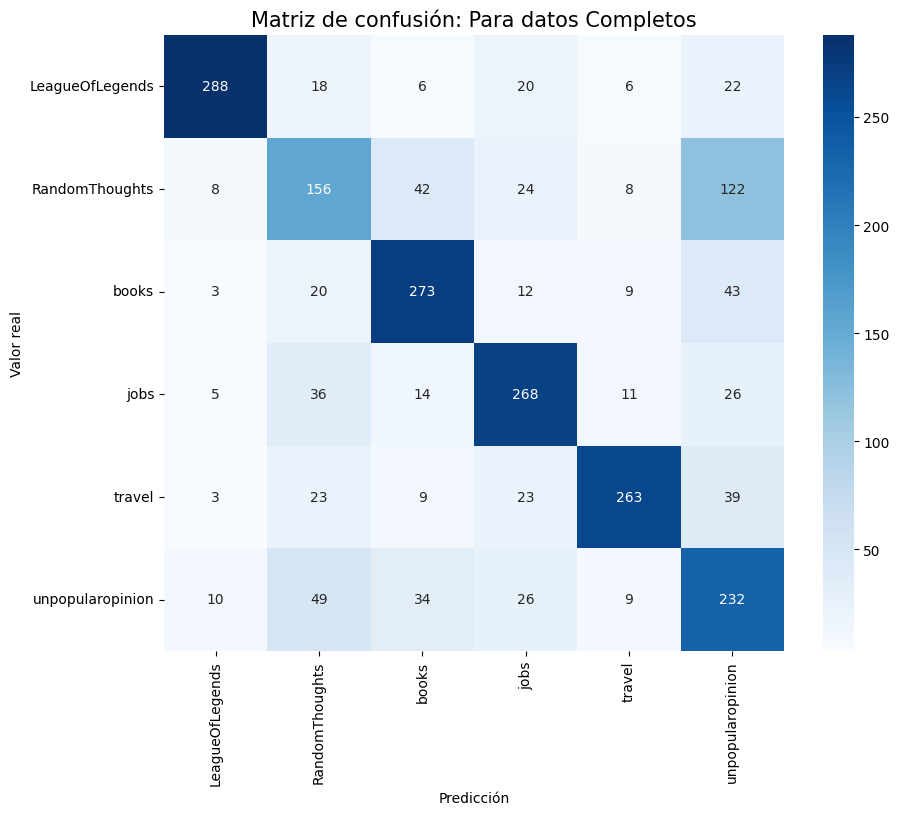

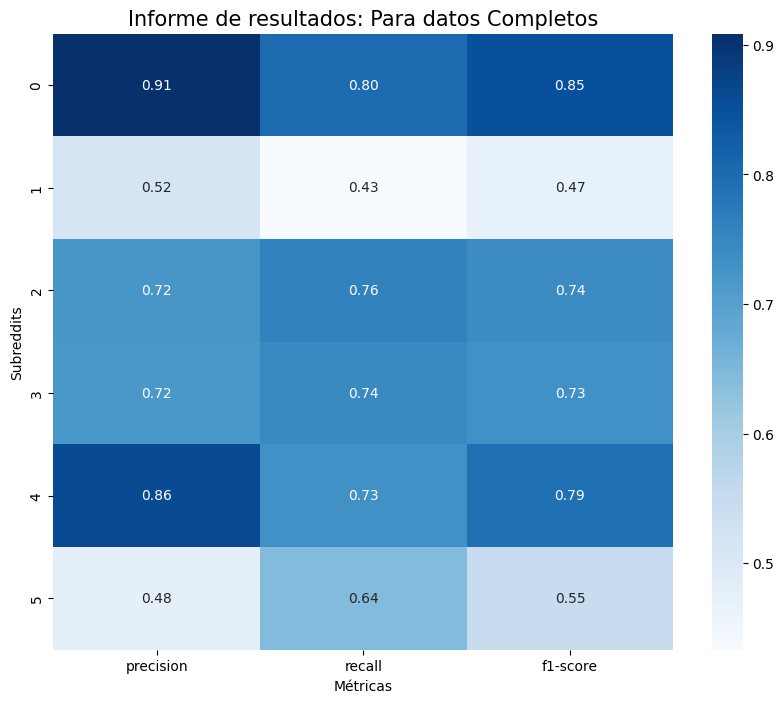

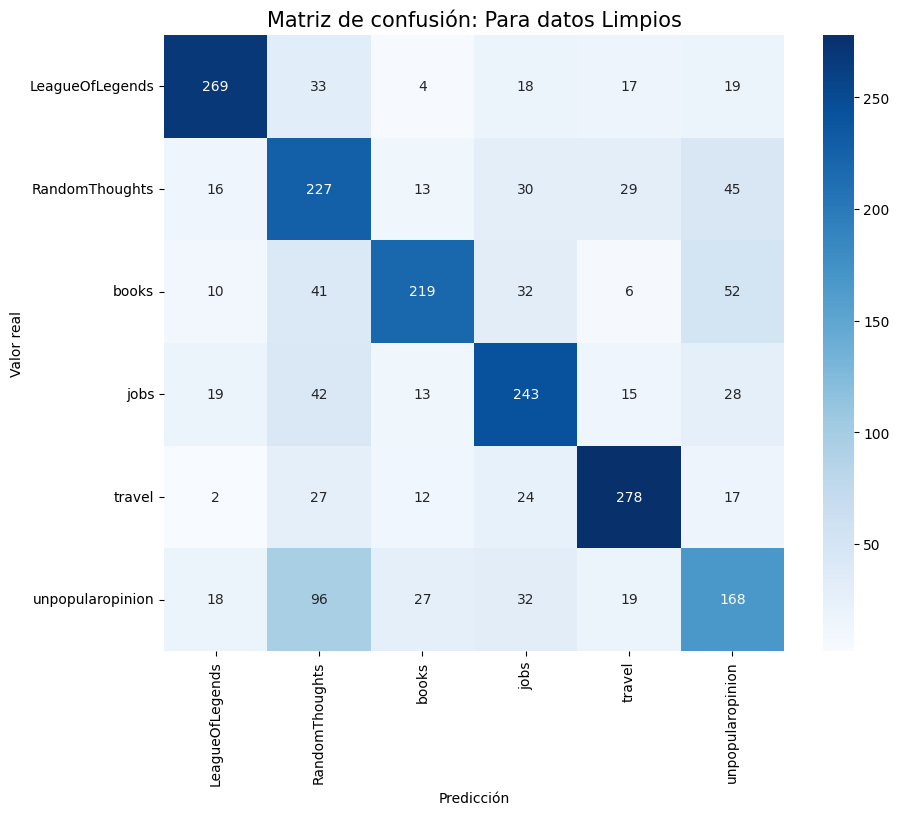

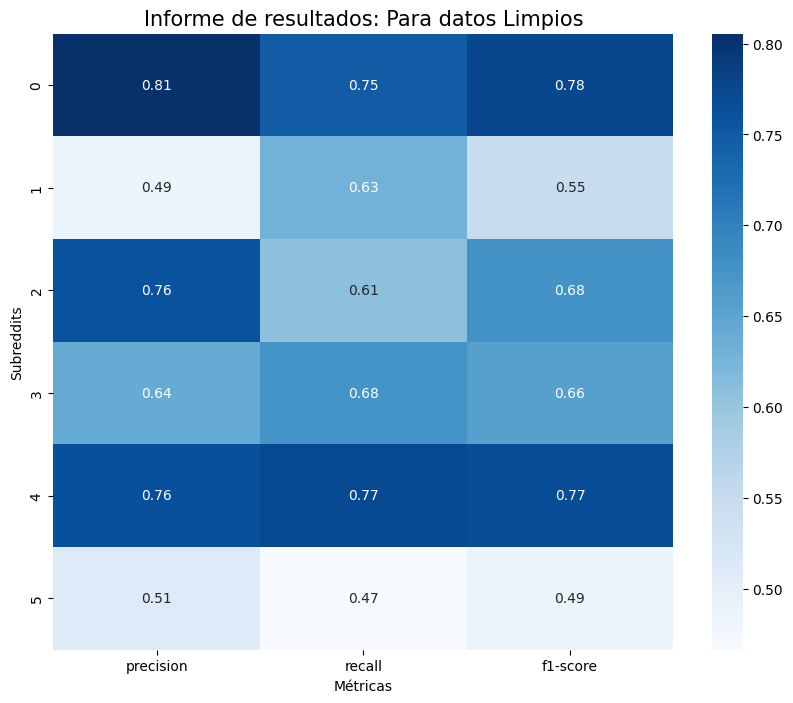

In [27]:
for datos, diccionario in resultados.items():
	titulo = f"Matriz de confusión: Para datos {datos}"
	plot_matriz_confusion(diccionario["Matriz de confusión"], titulo, etiquetas)

	titulo = f"Informe de resultados: Para datos {datos}"
	plot_informe_resultados(diccionario["Informe de resultados"], titulo)

Al emplear una estrategia de *fine-tuning* con este modelo de Transformer, hemos observado que el modelo aprovecha eficazmente el conocimiento lingüístico masivo con el que fue preentrenado originalmente. Hemos constatado que esto consigue compensar relativamente la limitación de tamaño de nuestro corpus, permitiendo al clasificador generalizar con una mayor precisión que los modelos anteriores ($68.51\%$ en el dataset completo y $65\%$ en el limpio).

## Conclusión resultados

Tras completar la comparativa entre los tres sistemas, hemos llegado a las siguientes conclusiones finales sobre el rendimiento de los modelos y la influencia del preprocesado:

*   **Resultados consistentes**: Es realmente notable que en todos los modelos son los subreddits **r/RandomThoughts** y **r/unpopularopinion** los que peor se consiguen clasificar, obteniendo los resultados más bajos y habitualmente confundiendo ambas comunidades entre sí. Resultado esperable teniendo en cuenta que el contenido de estas comunidades pueden llegar a ser parecidos, confundirse y ser los que más se parecen entre sí, pues un "pensamiento aleatorio" podría ser perfectamente una "opinión poco popular".
*   **Comparativa de Modelos**: Hemos observado que el sistema basado en **Transformers (BERT)** ofrece la mayor precisión, ya que su capacidad para entender el contexto compensa el tamaño limitado de nuestro corpus. Por el contrario, el enfoque de **Doc2Vec** ha resultado ineficaz para esta tarea, con resultados cercanos al azar ($15-17\%$) debido a que 5,000 comentarios son insuficientes para que un modelo aprenda relaciones semánticas desde cero. El sistema **TF-IDF** se posiciona como un punto medio muy sólido, logrando un notable $55\%$ de *accuracy* mediante un conteo estadístico sencillo.
*   **Utilidad de la Limpieza del Dataset**: En base a los resultados, concluimos que la limpieza de datos (eliminación de *stopwords* y ruido) tiene una utilidad muy baja, presenciando degradación en los resultados en los 3 modelos.

En resumen, mientras que la estadística simple de **TF-IDF** es suficiente para un primer filtrado, solo los modelos de **Transformers** logran capturar la complejidad semántica necesaria para clasificar correctamente el lenguaje natural de estos subreddits.